# Exercise 2 - NVDA Valuation Agent

This notebook implements Exercise 2 using the classroom valuation-agent framework.

The notebook covers:
1. Loading market, fundamentals, and sentiment inputs
2. Building point-in-time NVDA event input tables
3. Preparing baseline and sentiment-augmented valuation inputs
4. Running the valuation agent
5. Backtesting and comparing the two agent variants

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Setup

from pathlib import Path
import sys
import warnings

import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 200)

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().resolve().parent
else:
    PROJECT_ROOT = Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: D:\Desk\F550_final_peoject


## 1. Import local Exercise 2 utilities
Load helper functions used to construct NVDA event inputs.

In [18]:
# imports

from src_ex2.ex2_inputs import (
    build_nvda_event_inputs,
    build_nvda_event_inputs_from_manual_fundamentals,
    load_local_price_series,
)

from market_data import get_price_series
from sec_fundamentals import SecConfig, build_quarter_table

## 2. Load local sentiment outputs from Exercise 1
Use the call-level lexicon and FinBERT sentiment tables constructed in Exercise 1.

In [4]:
# load Exercise 1 call-level outputs

call_lex_path = PROCESSED_DIR / "ex1_call_lexicon_scores_2024.parquet"
call_finbert_path = PROCESSED_DIR / "ex1_call_finbert_scores_2024.parquet"

call_lex = pd.read_parquet(call_lex_path)
call_finbert = pd.read_parquet(call_finbert_path)

print("Call lexicon shape:", call_lex.shape)
print("Call FinBERT shape:", call_finbert.shape)

Call lexicon shape: (419, 8)
Call FinBERT shape: (419, 10)


## 3. Load NVDA prices and fundamentals
Load daily price data and construct the quarterly fundamentals table for NVDA.

In [8]:
# load NVDA prices

ticker = "NVDA"

local_price_path = RAW_DIR / "nvda_prices.csv"

prices = load_local_price_series(local_price_path)
prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index().astype(float)

print(prices.shape)
prices.tail()

(502,)


Date
2024-12-24    140.22
2024-12-26    139.93
2024-12-27    137.01
2024-12-30    137.49
2024-12-31    134.29
Name: Close, dtype: float64

In [9]:
# sanity check

print("Min date:", prices.index.min())
print("Max date:", prices.index.max())
print("Is monotonic increasing:", prices.index.is_monotonic_increasing)

print("\nHead:")
print(prices.head())

print("\nTail:")
print(prices.tail())

Min date: 2023-01-03 00:00:00
Max date: 2024-12-31 00:00:00
Is monotonic increasing: True

Head:
Date
2023-01-03    14.31
2023-01-04    14.75
2023-01-05    14.27
2023-01-06    14.86
2023-01-09    15.63
Name: Close, dtype: float64

Tail:
Date
2024-12-24    140.22
2024-12-26    139.93
2024-12-27    137.01
2024-12-30    137.49
2024-12-31    134.29
Name: Close, dtype: float64


In [10]:
# load NVDA quarter table

sec_cfg = SecConfig(user_agent="F550-final-project jinhao.he@outlook.com")

quarter_table = build_quarter_table(
    ticker=ticker,
    cfg=sec_cfg,
)

print(quarter_table.shape)
quarter_table.tail()

Using tag: RevenueFromContractWithCustomerExcludingAssessedTax
Using tag: EntityCommonStockSharesOutstanding
(59, 17)


,end,revenue_filed,revenue,op_income_filed,op_income,net_income_filed,net_income,ocf_filed,ocf,capex_filed,capex,shares_outstanding_filed,shares_outstanding,filed,fcf,fy,fp
54,2024-07-28,NaT,NaN,2025-08-27,1.864200e+10,2025-08-27,1.659900e+10,2025-08-27,1.448800e+10,NaT,NaN,NaT,NaN,2025-08-27,NaN,2026.0,Q2
55,2024-10-27,NaT,NaN,2025-11-19,2.186900e+10,2025-11-19,1.930900e+10,2025-11-19,1.762700e+10,NaT,NaN,NaT,NaN,2025-11-19,NaN,2026.0,Q3
56,2025-04-27,NaT,NaN,2025-05-28,2.163800e+10,2025-05-28,1.877500e+10,2025-05-28,2.741400e+10,NaT,NaN,NaT,NaN,2025-05-28,NaN,2026.0,Q1
57,2025-07-27,NaT,NaN,2025-08-27,2.844000e+10,2025-08-27,2.642200e+10,2025-08-27,1.536500e+10,NaT,NaN,NaT,NaN,2025-08-27,NaN,2026.0,Q2
58,2025-10-26,NaT,NaN,2025-11-19,3.601000e+10,2025-11-19,3.191000e+10,2025-11-19,2.375100e+10,NaT,NaN,NaT,NaN,2025-11-19,NaN,2026.0,Q3


## 4. Define evaluation dates
Use one representative trading date within each required window.

In [11]:
# define event dates

event_dates = {
    "feb_window": "2024-02-09",
    "aug_window": "2024-08-09",
}

event_dates

{'feb_window': '2024-02-09', 'aug_window': '2024-08-09'}

## 5. Build the NVDA event input table
Construct point-in-time valuation metrics and attach the latest available NVDA sentiment score before each evaluation date.

In [12]:
# build event input table

nvda_event_inputs = build_nvda_event_inputs(
    prices=prices,
    quarter_table=quarter_table,
    call_finbert=call_finbert,
    call_lex=call_lex,
    event_dates=event_dates,
)

print(nvda_event_inputs.shape)
nvda_event_inputs

(2, 12)


,event_label,evaluation_date,price,recent_5d_prices,ttm_revenue,ttm_net_income,ttm_fcf,ps,pe,p_fcf,sentiment_score_finbert,sentiment_score_lexicon
0,feb_window,2024-02-09,72.13,"[69.33, 68.22, 70.1, 69.64, 72.13]",None,NaN,None,None,None,None,NaN,NaN
1,aug_window,2024-08-09,104.75,"[100.45, 104.25, 98.91, 104.97, 104.75]",None,4.997000e+09,None,None,None,None,0.669439,0.555556


## 5A. Inspect NVDA quarterly fundamentals near the evaluation dates
Before running the valuation agent, inspect whether the classroom SEC helper produces usable point-in-time quarterly rows for NVDA.

In [13]:
qt = quarter_table.copy()
qt["end"] = pd.to_datetime(qt["end"], errors="coerce")
qt["filed"] = pd.to_datetime(qt["filed"], errors="coerce")

cols_to_show = [
    "end", "filed",
    "revenue", "net_income", "ocf", "capex", "fcf",
    "shares_outstanding",
    "fy", "fp",
]

qt.loc[
    (qt["end"] >= "2022-01-01") & (qt["end"] <= "2024-12-31"),
    cols_to_show
].sort_values("end").tail(20)

,end,filed,revenue,net_income,ocf,capex,fcf,shares_outstanding,fy,fp
46,2022-01-30,2022-03-18,2.691400e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,2022-05-01,2023-05-26,NaN,1.618000e+09,1.731000e+09,NaN,NaN,NaN,2024.0,Q1
48,2022-07-31,2023-08-28,NaN,6.560000e+08,1.270000e+09,NaN,NaN,NaN,2024.0,Q2
49,2022-10-30,2023-11-21,NaN,6.800000e+08,3.920000e+08,NaN,NaN,NaN,2024.0,Q3
50,2023-04-30,2024-05-29,NaN,2.043000e+09,2.911000e+09,NaN,NaN,NaN,2025.0,Q1
51,2023-07-30,2024-08-28,NaN,6.188000e+09,6.348000e+09,NaN,NaN,NaN,2025.0,Q2
52,2023-10-29,2024-11-20,NaN,9.243000e+09,7.332000e+09,NaN,NaN,NaN,2025.0,Q3
53,2024-04-28,2025-05-28,NaN,1.488100e+10,1.534500e+10,NaN,NaN,NaN,2026.0,Q1
54,2024-07-28,2025-08-27,NaN,1.659900e+10,1.448800e+10,NaN,NaN,NaN,2026.0,Q2
55,2024-10-27,2025-11-19,NaN,1.930900e+10,1.762700e+10,NaN,NaN,NaN,2026.0,Q3


In [14]:
qt_feb = qt.loc[qt["filed"] <= "2024-02-09"].copy()

print("Rows available as of 2024-02-09:", qt_feb.shape[0])

qt_feb[
    ["end", "filed", "revenue", "net_income", "fcf", "shares_outstanding", "fy", "fp"]
].sort_values("end").tail(12)

Rows available as of 2024-02-09: 50


,end,filed,revenue,net_income,fcf,shares_outstanding,fy,fp
38,2020-01-26,2022-03-18,1.091800e+10,NaN,NaN,NaN,NaN,NaN
39,2020-04-26,2021-05-26,NaN,9.170000e+08,7.540000e+08,NaN,2022.0,Q1
40,2020-07-26,2021-08-20,NaN,6.220000e+08,1.350000e+09,NaN,2022.0,Q2
41,2020-10-25,2021-11-22,NaN,1.336000e+09,NaN,NaN,2022.0,Q3
42,2021-01-31,2022-03-18,1.667500e+10,NaN,NaN,NaN,NaN,NaN
43,2021-05-02,2022-05-27,NaN,1.912000e+09,NaN,NaN,2023.0,Q1
44,2021-08-01,2022-08-31,NaN,2.374000e+09,NaN,NaN,2023.0,Q2
45,2021-10-31,2022-11-18,NaN,2.464000e+09,NaN,NaN,2023.0,Q3
46,2022-01-30,2022-03-18,2.691400e+10,NaN,NaN,NaN,NaN,NaN
47,2022-05-01,2023-05-26,NaN,1.618000e+09,NaN,NaN,2024.0,Q1


In [15]:
qt_aug = qt.loc[qt["filed"] <= "2024-08-09"].copy()

print("Rows available as of 2024-08-09:", qt_aug.shape[0])

qt_aug[
    ["end", "filed", "revenue", "net_income", "fcf", "shares_outstanding", "fy", "fp"]
].sort_values("end").tail(12)

Rows available as of 2024-08-09: 51


,end,filed,revenue,net_income,fcf,shares_outstanding,fy,fp
39,2020-04-26,2021-05-26,NaN,9.170000e+08,7.540000e+08,NaN,2022.0,Q1
40,2020-07-26,2021-08-20,NaN,6.220000e+08,1.350000e+09,NaN,2022.0,Q2
41,2020-10-25,2021-11-22,NaN,1.336000e+09,NaN,NaN,2022.0,Q3
42,2021-01-31,2022-03-18,1.667500e+10,NaN,NaN,NaN,NaN,NaN
43,2021-05-02,2022-05-27,NaN,1.912000e+09,NaN,NaN,2023.0,Q1
44,2021-08-01,2022-08-31,NaN,2.374000e+09,NaN,NaN,2023.0,Q2
45,2021-10-31,2022-11-18,NaN,2.464000e+09,NaN,NaN,2023.0,Q3
46,2022-01-30,2022-03-18,2.691400e+10,NaN,NaN,NaN,NaN,NaN
47,2022-05-01,2023-05-26,NaN,1.618000e+09,NaN,NaN,2024.0,Q1
48,2022-07-31,2023-08-28,NaN,6.560000e+08,NaN,NaN,2024.0,Q2


In [16]:
print("Missingness as of 2024-02-09:")
print(qt_feb[["revenue", "net_income", "fcf", "shares_outstanding"]].isna().sum())

print("\nMissingness as of 2024-08-09:")
print(qt_aug[["revenue", "net_income", "fcf", "shares_outstanding"]].isna().sum())

Missingness as of 2024-02-09:
revenue               35
net_income             6
fcf                   23
shares_outstanding    50
dtype: int64

Missingness as of 2024-08-09:
revenue               36
net_income             6
fcf                   24
shares_outstanding    51
dtype: int64


## 5B. Manual TTM fundamentals fallback
Because the classroom SEC helper does not produce a complete point-in-time quarterly table for NVDA, a small manual TTM fundamentals table is used for the two required evaluation windows.

In [20]:
# build manual fundamentals table

manual_fundamentals = pd.DataFrame(
    [
        {
            "event_label": "feb_window",
            "evaluation_date": "2024-02-09",
            "ttm_revenue": 44.870e9,
            "ttm_net_income": 18.888e9,
            "ttm_fcf": 17.469e9,
            "shares_outstanding": 24.70e9,
            "market_cap": 1.781611e12,
            "ps": 39.7061,
            "pe": 94.3250,
            "p_fcf": 101.9870,
        },
        {
            "event_label": "aug_window",
            "evaluation_date": "2024-08-09",
            "ttm_revenue": 79.774e9,
            "ttm_net_income": 42.597e9,
            "ttm_fcf": 39.243e9,
            "shares_outstanding": 24.60e9,
            "market_cap": 2.576850e12,
            "ps": 32.3019,
            "pe": 60.4937,
            "p_fcf": 65.6639,
        },
    ]
)

manual_fundamentals

,event_label,evaluation_date,ttm_revenue,ttm_net_income,ttm_fcf,shares_outstanding,market_cap,ps,pe,p_fcf
0,feb_window,2024-02-09,4.487000e+10,1.888800e+10,1.746900e+10,2.470000e+10,1.781611e+12,39.7061,94.3250,101.9870
1,aug_window,2024-08-09,7.977400e+10,4.259700e+10,3.924300e+10,2.460000e+10,2.576850e+12,32.3019,60.4937,65.6639


In [21]:
# rebuild event input table using manual fundamentals

from src_ex2.ex2_inputs import build_nvda_event_inputs_from_manual_fundamentals

nvda_event_inputs = build_nvda_event_inputs_from_manual_fundamentals(
    prices=prices,
    call_finbert=call_finbert,
    call_lex=call_lex,
    manual_fundamentals=manual_fundamentals,
    event_dates=event_dates,
)

print(nvda_event_inputs.shape)
nvda_event_inputs

(2, 14)


,event_label,evaluation_date,price,recent_5d_prices,ttm_revenue,ttm_net_income,ttm_fcf,shares_outstanding,market_cap,ps,pe,p_fcf,sentiment_score_finbert,sentiment_score_lexicon
0,feb_window,2024-02-09,72.13,"[69.33, 68.22, 70.1, 69.64, 72.13]",4.487000e+10,1.888800e+10,1.746900e+10,2.470000e+10,1.781611e+12,39.7061,94.3250,101.9870,0.000000,0.000000
1,aug_window,2024-08-09,104.75,"[100.45, 104.25, 98.91, 104.97, 104.75]",7.977400e+10,4.259700e+10,3.924300e+10,2.460000e+10,2.576850e+12,32.3019,60.4937,65.6639,0.669439,0.555556


## 5C. Save the NVDA event input table
Save the final Exercise 2 event input table for downstream agent evaluation.

In [22]:
# save event inputs

nvda_event_inputs_path = PROCESSED_DIR / "ex2_nvda_event_inputs_2024.parquet"
nvda_event_inputs.to_parquet(nvda_event_inputs_path, index=False)

print("Saved NVDA event input table to:", nvda_event_inputs_path)

Saved NVDA event input table to: D:\Desk\F550_final_peoject\data\processed\ex2_nvda_event_inputs_2024.parquet


## 6. Build agent-ready event inputs
Convert the event input table into valuation-agent input objects for the baseline and sentiment-augmented agent variants.

In [23]:
# import new agent classes

from src_ex2.ex2_agent import Ex2ValuationInput, Ex2ValuationAgent

In [24]:
# convert dataframe rows into agent inputs

def make_ex2_input(row, use_sentiment: bool) -> Ex2ValuationInput:
    return Ex2ValuationInput(
        event_label=row["event_label"],
        evaluation_date=pd.Timestamp(row["evaluation_date"]),
        price=float(row["price"]),
        recent_5d_prices=list(row["recent_5d_prices"]),
        ttm_revenue=row["ttm_revenue"],
        ttm_net_income=row["ttm_net_income"],
        ttm_fcf=row["ttm_fcf"],
        ps=row["ps"],
        pe=row["pe"],
        p_fcf=row["p_fcf"],
        sentiment_score=row["sentiment_score_finbert"] if use_sentiment else None,
    )


In [25]:
# build baseline and sentiment input lists

baseline_inputs = [
    make_ex2_input(row, use_sentiment=False)
    for _, row in nvda_event_inputs.iterrows()
]

sentiment_inputs = [
    make_ex2_input(row, use_sentiment=True)
    for _, row in nvda_event_inputs.iterrows()
]

print("Baseline inputs:", len(baseline_inputs))
print("Sentiment inputs:", len(sentiment_inputs))
baseline_inputs[0]

Baseline inputs: 2
Sentiment inputs: 2


Ex2ValuationInput(event_label='feb_window', evaluation_date=Timestamp('2024-02-09 00:00:00'), price=72.13, recent_5d_prices=[69.33, 68.22, 70.1, 69.64, 72.13], ttm_revenue=44870000000.0, ttm_net_income=18888000000.0, ttm_fcf=17469000000.0, ps=39.7061, pe=94.325, p_fcf=101.987, sentiment_score=None)

## 7. Connect an OpenAI LLM backend
Use a ChatGPT model through the OpenAI Responses API to generate valuation decisions.

In [26]:
# imports

from src_ex2.ex2_openai_backend import OpenAIResponsesBackend

In [ ]:
# test

import os
from openai import OpenAI

os.environ["OPENAI_API_KEY"] = ""

client = OpenAI()

models = client.models.list()
for m in models.data:
    print(m.id)

gpt-3.5-turbo
gpt-5.4-mini
gpt-5.4
gpt-5.4-nano-2026-03-17
gpt-5.4-nano
gpt-5.4-mini-2026-03-17
davinci-002
babbage-002
gpt-3.5-turbo-instruct
gpt-3.5-turbo-instruct-0914
dall-e-3
dall-e-2
gpt-3.5-turbo-1106
tts-1-hd
tts-1-1106
tts-1-hd-1106
text-embedding-3-small
text-embedding-3-large
gpt-3.5-turbo-0125
gpt-4o
gpt-4o-2024-05-13
gpt-4o-mini-2024-07-18
gpt-4o-mini
gpt-4o-2024-08-06
gpt-4o-audio-preview
omni-moderation-latest
omni-moderation-2024-09-26
gpt-4o-audio-preview-2024-12-17
gpt-4o-mini-audio-preview-2024-12-17
o1-2024-12-17
o1
gpt-4o-mini-audio-preview
o3-mini
o3-mini-2025-01-31
gpt-4o-2024-11-20
gpt-4o-mini-search-preview-2025-03-11
gpt-4o-mini-search-preview
gpt-4o-transcribe
gpt-4o-mini-transcribe
gpt-4o-mini-tts
o3-2025-04-16
o4-mini-2025-04-16
o3
o4-mini
gpt-4.1-2025-04-14
gpt-4.1
gpt-4.1-mini-2025-04-14
gpt-4.1-mini
gpt-4.1-nano-2025-04-14
gpt-4.1-nano
gpt-image-1
gpt-4o-audio-preview-2025-06-03
gpt-4o-transcribe-diarize
gpt-5-chat-latest
gpt-5-2025-08-07
gpt-5
gpt-5-min

In [ ]:
# test

OPENAI_MODEL = "gpt-4o"

llm_backend = OpenAIResponsesBackend(
    model=OPENAI_MODEL,
    temperature=0.2,
    max_output_tokens=200,
)

test_resp = llm_backend.chat(
    [
        {"role": "system", "content": "Be concise."},
        {"role": "user", "content": "Say hello in one sentence."},
    ]
)

test_resp

{'content': 'Hello! How can I assist you today?'}

In [32]:
# initialize backend

OPENAI_MODEL = "gpt-4o"

llm_backend = OpenAIResponsesBackend(
    model=OPENAI_MODEL,
    temperature=0.2,
    max_output_tokens=400,
)

## 8. Initialize the two Exercise 2 agent variants
Create:
1. A baseline valuation agent without sentiment
2. A sentiment-augmented valuation agent

In [33]:
# initialize agents

baseline_agent = Ex2ValuationAgent(
    llm_backend=llm_backend,
    agent_type="baseline",
)

sentiment_agent = Ex2ValuationAgent(
    llm_backend=llm_backend,
    agent_type="sentiment",
)

## 9. Run agent decisions for the two event windows
Generate Buy/Sell/Hold decisions, confidence scores, and investment theses for both agent variants.

In [34]:
# run baseline decisions

baseline_decisions = [baseline_agent.decide(vin) for vin in baseline_inputs]
baseline_decisions

[Ex2Decision(event_label='feb_window', evaluation_date=Timestamp('2024-02-09 00:00:00'), action='sell', confidence=0.8, score=-0.7, thesis="NVDA's current valuation multiples are significantly high, with a P/E of 94.325 and a P/FCF of 101.987, indicating a premium pricing relative to its earnings and cash flow generation. Despite strong revenue and net income figures, the elevated multiples suggest limited upside potential and increased risk of correction. Given the recent price increase and the conservative approach, a Sell rating is warranted to mitigate potential downside.", agent_type='baseline'),
 Ex2Decision(event_label='aug_window', evaluation_date=Timestamp('2024-08-09 00:00:00'), action='sell', confidence=0.8, score=-0.7, thesis="NVDA's current valuation multiples are significantly higher than industry averages, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66. Despite strong revenue and net income growth, the high multiples suggest overvaluation relative to fundamentals.

In [35]:
# run sentiment decisions

sentiment_decisions = [sentiment_agent.decide(vin) for vin in sentiment_inputs]
sentiment_decisions

[Ex2Decision(event_label='feb_window', evaluation_date=Timestamp('2024-02-09 00:00:00'), action='sell', confidence=0.8, score=-0.5, thesis="NVDA's current valuation multiples are significantly high, with a P/E of 94.325 and a P/FCF of 101.987, suggesting the stock is overvalued relative to its earnings and cash flow. The sentiment score of 0.0 from the latest earnings call indicates a neutral to negative outlook, lacking positive catalysts. Given the elevated multiples and neutral sentiment, a conservative approach would be to sell, as the risk of a price correction outweighs potential upside.", agent_type='sentiment'),
 Ex2Decision(event_label='aug_window', evaluation_date=Timestamp('2024-08-09 00:00:00'), action='sell', confidence=0.8, score=-0.5, thesis="NVDA's current valuation multiples are significantly high, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66, indicating a premium pricing relative to its fundamentals. Despite strong TTM revenue and net income figures, the elev

In [36]:
# convert decisions to DataFrame

baseline_df = pd.DataFrame([d.__dict__ for d in baseline_decisions])
sentiment_df = pd.DataFrame([d.__dict__ for d in sentiment_decisions])

print("Baseline decisions:")
display(baseline_df)

print("Sentiment decisions:")
display(sentiment_df)

Baseline decisions:


,event_label,evaluation_date,action,confidence,score,thesis,agent_type
0,feb_window,2024-02-09,sell,0.8,-0.7,"NVDA's current valuation multiples are significantly high, with a P/E of 94.325 and a P/FCF of 101.987, indicating a premium pricing relative to its earnings and cash flow generation. Despite stro...",baseline
1,aug_window,2024-08-09,sell,0.8,-0.7,"NVDA's current valuation multiples are significantly higher than industry averages, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66. Despite strong revenue and net income growth, the high mu...",baseline


Sentiment decisions:


,event_label,evaluation_date,action,confidence,score,thesis,agent_type
0,feb_window,2024-02-09,sell,0.8,-0.5,"NVDA's current valuation multiples are significantly high, with a P/E of 94.325 and a P/FCF of 101.987, suggesting the stock is overvalued relative to its earnings and cash flow. The sentiment sco...",sentiment
1,aug_window,2024-08-09,sell,0.8,-0.5,"NVDA's current valuation multiples are significantly high, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66, indicating a premium pricing relative to its fundamentals. Despite strong TTM reve...",sentiment


In [37]:
# merge for comparision 

decision_compare = baseline_df.merge(
    sentiment_df,
    on=["event_label", "evaluation_date"],
    how="outer",
    suffixes=("_baseline", "_sentiment"),
)

decision_compare

,event_label,evaluation_date,action_baseline,confidence_baseline,score_baseline,thesis_baseline,agent_type_baseline,action_sentiment,confidence_sentiment,score_sentiment,thesis_sentiment,agent_type_sentiment
0,aug_window,2024-08-09,sell,0.8,-0.7,"NVDA's current valuation multiples are significantly higher than industry averages, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66. Despite strong revenue and net income growth, the high mu...",baseline,sell,0.8,-0.5,"NVDA's current valuation multiples are significantly high, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66, indicating a premium pricing relative to its fundamentals. Despite strong TTM reve...",sentiment
1,feb_window,2024-02-09,sell,0.8,-0.7,"NVDA's current valuation multiples are significantly high, with a P/E of 94.325 and a P/FCF of 101.987, indicating a premium pricing relative to its earnings and cash flow generation. Despite stro...",baseline,sell,0.8,-0.5,"NVDA's current valuation multiples are significantly high, with a P/E of 94.325 and a P/FCF of 101.987, suggesting the stock is overvalued relative to its earnings and cash flow. The sentiment sco...",sentiment


## 10. Backtest the two agent variants
Backtest the baseline and sentiment-augmented decision rules using an event-driven strategy with shorting enabled.

In [38]:
# imports

from src_ex2.ex2_backtest import (
    StaticDecisionAgent,
    build_decision_mapping,
    annualized_sharpe,
)

from backtester import EventBacktester, BacktestConfig

In [39]:
# rename decision DataFrames to clean format

baseline_bt_df = baseline_df.rename(
    columns={
        "action": "action",
        "confidence": "confidence",
        "score": "score",
        "thesis": "thesis",
    }
).copy()

sentiment_bt_df = sentiment_df.rename(
    columns={
        "action": "action",
        "confidence": "confidence",
        "score": "score",
        "thesis": "thesis",
    }
).copy()

baseline_bt_df

,event_label,evaluation_date,action,confidence,score,thesis,agent_type
0,feb_window,2024-02-09,sell,0.8,-0.7,"NVDA's current valuation multiples are significantly high, with a P/E of 94.325 and a P/FCF of 101.987, indicating a premium pricing relative to its earnings and cash flow generation. Despite stro...",baseline
1,aug_window,2024-08-09,sell,0.8,-0.7,"NVDA's current valuation multiples are significantly higher than industry averages, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66. Despite strong revenue and net income growth, the high mu...",baseline


In [43]:
# build decision mappings

baseline_decisions_by_date = build_decision_mapping(baseline_bt_df)
sentiment_decisions_by_date = build_decision_mapping(sentiment_bt_df)

baseline_static_agent = StaticDecisionAgent(baseline_decisions_by_date)
sentiment_static_agent = StaticDecisionAgent(sentiment_decisions_by_date)

In [44]:
# build valuation input mapping for backtester

valuation_inputs_by_event_date = {
    pd.Timestamp(vin.evaluation_date): vin
    for vin in baseline_inputs
}

valuation_inputs_by_event_date

{Timestamp('2024-02-09 00:00:00'): Ex2ValuationInput(event_label='feb_window', evaluation_date=Timestamp('2024-02-09 00:00:00'), price=72.13, recent_5d_prices=[69.33, 68.22, 70.1, 69.64, 72.13], ttm_revenue=44870000000.0, ttm_net_income=18888000000.0, ttm_fcf=17469000000.0, ps=39.7061, pe=94.325, p_fcf=101.987, sentiment_score=None),
 Timestamp('2024-08-09 00:00:00'): Ex2ValuationInput(event_label='aug_window', evaluation_date=Timestamp('2024-08-09 00:00:00'), price=104.75, recent_5d_prices=[100.45, 104.25, 98.91, 104.97, 104.75], ttm_revenue=79774000000.0, ttm_net_income=42597000000.0, ttm_fcf=39243000000.0, ps=32.3019, pe=60.4937, p_fcf=65.6639, sentiment_score=None)}

In [49]:
# run baseline backtest

bt = EventBacktester(
    prices=prices,
    cfg=BacktestConfig(
        initial_cash=100_000.0,
        transaction_cost_bps=10.0,
        trade_size_units=5.0,
        allow_short=True,
    ),
)

baseline_bt = bt.run(
    ticker="NVDA",
    agent=baseline_static_agent,
    valuation_inputs_by_event_date=valuation_inputs_by_event_date,
)

baseline_bt.loc["2024-02-05":"2024-02-15"]
baseline_bt.loc["2024-08-05":"2024-08-15"]

,ticker,price,action,position,cash,portfolio_value,decision_score,decision_confidence,decision_thesis,returns
date,,,,,,,,,,
2024-08-05,NVDA,100.45,sell,-5.0,100360.28935,99858.03935,-0.7,0.8,"NVDA's current valuation multiples are significantly high, with a P/E of 94.325 and a P/FCF of 101.987, indicating a premium pricing relative to its earnings and cash flow generation. Despite stro...",0.000342
2024-08-06,NVDA,104.25,sell,-5.0,100360.28935,99839.03935,-0.7,0.8,"NVDA's current valuation multiples are significantly high, with a P/E of 94.325 and a P/FCF of 101.987, indicating a premium pricing relative to its earnings and cash flow generation. Despite stro...",-0.000190
2024-08-07,NVDA,98.91,sell,-5.0,100360.28935,99865.73935,-0.7,0.8,"NVDA's current valuation multiples are significantly high, with a P/E of 94.325 and a P/FCF of 101.987, indicating a premium pricing relative to its earnings and cash flow generation. Despite stro...",0.000267
2024-08-08,NVDA,104.97,sell,-5.0,100360.28935,99835.43935,-0.7,0.8,"NVDA's current valuation multiples are significantly high, with a P/E of 94.325 and a P/FCF of 101.987, indicating a premium pricing relative to its earnings and cash flow generation. Despite stro...",-0.000303
2024-08-09,NVDA,104.75,sell,-10.0,100883.51560,99836.01560,-0.7,0.8,"NVDA's current valuation multiples are significantly higher than industry averages, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66. Despite strong revenue and net income growth, the high mu...",0.000006
2024-08-12,NVDA,109.02,sell,-10.0,100883.51560,99793.31560,-0.7,0.8,"NVDA's current valuation multiples are significantly higher than industry averages, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66. Despite strong revenue and net income growth, the high mu...",-0.000428
2024-08-13,NVDA,116.14,sell,-10.0,100883.51560,99722.11560,-0.7,0.8,"NVDA's current valuation multiples are significantly higher than industry averages, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66. Despite strong revenue and net income growth, the high mu...",-0.000713
2024-08-14,NVDA,118.08,sell,-10.0,100883.51560,99702.71560,-0.7,0.8,"NVDA's current valuation multiples are significantly higher than industry averages, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66. Despite strong revenue and net income growth, the high mu...",-0.000195
2024-08-15,NVDA,122.86,sell,-10.0,100883.51560,99654.91560,-0.7,0.8,"NVDA's current valuation multiples are significantly higher than industry averages, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66. Despite strong revenue and net income growth, the high mu...",-0.000479


In [50]:
# run sentiment backtest

bt2 = EventBacktester(
    prices=prices,
    cfg=BacktestConfig(
        initial_cash=100_000.0,
        transaction_cost_bps=10.0,
        trade_size_units=5.0,
        allow_short=True,
    ),
)

sentiment_bt = bt2.run(
    ticker="NVDA",
    agent=sentiment_static_agent,
    valuation_inputs_by_event_date=valuation_inputs_by_event_date,
)

sentiment_bt.loc["2024-02-05":"2024-02-15"]
sentiment_bt.loc["2024-08-05":"2024-08-15"]

,ticker,price,action,position,cash,portfolio_value,decision_score,decision_confidence,decision_thesis,returns
date,,,,,,,,,,
2024-08-05,NVDA,100.45,sell,-5.0,100360.28935,99858.03935,-0.5,0.8,"NVDA's current valuation multiples are significantly high, with a P/E of 94.325 and a P/FCF of 101.987, suggesting the stock is overvalued relative to its earnings and cash flow. The sentiment sco...",0.000342
2024-08-06,NVDA,104.25,sell,-5.0,100360.28935,99839.03935,-0.5,0.8,"NVDA's current valuation multiples are significantly high, with a P/E of 94.325 and a P/FCF of 101.987, suggesting the stock is overvalued relative to its earnings and cash flow. The sentiment sco...",-0.000190
2024-08-07,NVDA,98.91,sell,-5.0,100360.28935,99865.73935,-0.5,0.8,"NVDA's current valuation multiples are significantly high, with a P/E of 94.325 and a P/FCF of 101.987, suggesting the stock is overvalued relative to its earnings and cash flow. The sentiment sco...",0.000267
2024-08-08,NVDA,104.97,sell,-5.0,100360.28935,99835.43935,-0.5,0.8,"NVDA's current valuation multiples are significantly high, with a P/E of 94.325 and a P/FCF of 101.987, suggesting the stock is overvalued relative to its earnings and cash flow. The sentiment sco...",-0.000303
2024-08-09,NVDA,104.75,sell,-10.0,100883.51560,99836.01560,-0.5,0.8,"NVDA's current valuation multiples are significantly high, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66, indicating a premium pricing relative to its fundamentals. Despite strong TTM reve...",0.000006
2024-08-12,NVDA,109.02,sell,-10.0,100883.51560,99793.31560,-0.5,0.8,"NVDA's current valuation multiples are significantly high, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66, indicating a premium pricing relative to its fundamentals. Despite strong TTM reve...",-0.000428
2024-08-13,NVDA,116.14,sell,-10.0,100883.51560,99722.11560,-0.5,0.8,"NVDA's current valuation multiples are significantly high, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66, indicating a premium pricing relative to its fundamentals. Despite strong TTM reve...",-0.000713
2024-08-14,NVDA,118.08,sell,-10.0,100883.51560,99702.71560,-0.5,0.8,"NVDA's current valuation multiples are significantly high, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66, indicating a premium pricing relative to its fundamentals. Despite strong TTM reve...",-0.000195
2024-08-15,NVDA,122.86,sell,-10.0,100883.51560,99654.91560,-0.5,0.8,"NVDA's current valuation multiples are significantly high, with a P/E of 60.49, P/S of 32.30, and P/FCF of 65.66, indicating a premium pricing relative to its fundamentals. Despite strong TTM reve...",-0.000479


In [47]:
# compute Sharpe ratios

baseline_sharpe = annualized_sharpe(baseline_bt["returns"])
sentiment_sharpe = annualized_sharpe(sentiment_bt["returns"])

print("Baseline Sharpe:", baseline_sharpe)
print("Sentiment Sharpe:", sentiment_sharpe)

Baseline Sharpe: -0.7879326729377765
Sentiment Sharpe: -0.7879326729377765


In [48]:
# compare ending portfolio values

backtest_compare = pd.DataFrame(
    {
        "agent_type": ["baseline", "sentiment"],
        "ending_portfolio_value": [
            baseline_bt["portfolio_value"].iloc[-1],
            sentiment_bt["portfolio_value"].iloc[-1],
        ],
        "cumulative_return": [
            baseline_bt["portfolio_value"].iloc[-1] / baseline_bt["portfolio_value"].iloc[0] - 1,
            sentiment_bt["portfolio_value"].iloc[-1] / sentiment_bt["portfolio_value"].iloc[0] - 1,
        ],
        "sharpe_ratio": [baseline_sharpe, sentiment_sharpe],
    }
)

backtest_compare

,agent_type,ending_portfolio_value,cumulative_return,sharpe_ratio
0,baseline,99540.6156,-0.004594,-0.787933
1,sentiment,99540.6156,-0.004594,-0.787933


## 11. Run a score-based event backtest
Because both agent variants produce the same discrete action (`sell`) at both event dates, a score-based backtest is used to compare differences in signal strength.

In [51]:
# imports

from src_ex2.ex2_backtest import (
    ScoreBacktestConfig,
    build_score_mapping,
    run_score_based_backtest,
    annualized_sharpe,
)

In [52]:
# scorce mapping

baseline_score_map = build_score_mapping(baseline_df)
sentiment_score_map = build_score_mapping(sentiment_df)

baseline_score_map, sentiment_score_map

({Timestamp('2024-02-09 00:00:00'): -0.7,
  Timestamp('2024-08-09 00:00:00'): -0.7},
 {Timestamp('2024-02-09 00:00:00'): -0.5,
  Timestamp('2024-08-09 00:00:00'): -0.5})

In [53]:
# score-based backtest

score_bt_cfg = ScoreBacktestConfig(
    initial_cash=100_000.0,
    max_units=10.0,
    transaction_cost_bps=10.0,
)

baseline_score_bt = run_score_based_backtest(
    prices=prices,
    score_by_date=baseline_score_map,
    cfg=score_bt_cfg,
    ticker="NVDA",
)

sentiment_score_bt = run_score_based_backtest(
    prices=prices,
    score_by_date=sentiment_score_map,
    cfg=score_bt_cfg,
    ticker="NVDA",
)

baseline_score_bt.head(), sentiment_score_bt.head()

(           ticker  price action  position      cash  portfolio_value  decision_score  returns
 date                                                                                         
 2023-01-03   NVDA  14.31   hold       0.0  100000.0         100000.0             NaN      0.0
 2023-01-04   NVDA  14.75   hold       0.0  100000.0         100000.0             NaN      0.0
 2023-01-05   NVDA  14.27   hold       0.0  100000.0         100000.0             NaN      0.0
 2023-01-06   NVDA  14.86   hold       0.0  100000.0         100000.0             NaN      0.0
 2023-01-09   NVDA  15.63   hold       0.0  100000.0         100000.0             NaN      0.0,
            ticker  price action  position      cash  portfolio_value  decision_score  returns
 date                                                                                         
 2023-01-03   NVDA  14.31   hold       0.0  100000.0         100000.0             NaN      0.0
 2023-01-04   NVDA  14.75   hold       0.0  10000

In [55]:
baseline_score_bt.loc["2024-02-05":"2024-02-15"]

,ticker,price,action,position,cash,portfolio_value,decision_score,returns
date,,,,,,,,
2024-02-05,NVDA,69.33,hold,0.0,100000.00000,100000.00000,NaN,0.000000
2024-02-06,NVDA,68.22,hold,0.0,100000.00000,100000.00000,NaN,0.000000
2024-02-07,NVDA,70.10,hold,0.0,100000.00000,100000.00000,NaN,0.000000
2024-02-08,NVDA,69.64,hold,0.0,100000.00000,100000.00000,NaN,0.000000
2024-02-09,NVDA,72.13,sell,-7.0,100504.40509,99999.49509,-0.7,-0.000005
2024-02-12,NVDA,72.25,hold,-7.0,100504.40509,99998.65509,NaN,-0.000008
2024-02-13,NVDA,72.13,hold,-7.0,100504.40509,99999.49509,NaN,0.000008
2024-02-14,NVDA,73.90,hold,-7.0,100504.40509,99987.10509,NaN,-0.000124
2024-02-15,NVDA,72.66,hold,-7.0,100504.40509,99995.78509,NaN,0.000087


In [56]:
sentiment_score_bt.loc["2024-02-05":"2024-02-15"]

,ticker,price,action,position,cash,portfolio_value,decision_score,returns
date,,,,,,,,
2024-02-05,NVDA,69.33,hold,0.0,100000.00000,100000.00000,NaN,0.000000
2024-02-06,NVDA,68.22,hold,0.0,100000.00000,100000.00000,NaN,0.000000
2024-02-07,NVDA,70.10,hold,0.0,100000.00000,100000.00000,NaN,0.000000
2024-02-08,NVDA,69.64,hold,0.0,100000.00000,100000.00000,NaN,0.000000
2024-02-09,NVDA,72.13,sell,-5.0,100360.28935,99999.63935,-0.5,-0.000004
2024-02-12,NVDA,72.25,hold,-5.0,100360.28935,99999.03935,NaN,-0.000006
2024-02-13,NVDA,72.13,hold,-5.0,100360.28935,99999.63935,NaN,0.000006
2024-02-14,NVDA,73.90,hold,-5.0,100360.28935,99990.78935,NaN,-0.000089
2024-02-15,NVDA,72.66,hold,-5.0,100360.28935,99996.98935,NaN,0.000062


In [57]:
baseline_score_bt.loc["2024-08-05":"2024-08-15"]

,ticker,price,action,position,cash,portfolio_value,decision_score,returns
date,,,,,,,,
2024-08-05,NVDA,100.45,hold,-7.0,100504.40509,99801.25509,NaN,0.000479
2024-08-06,NVDA,104.25,hold,-7.0,100504.40509,99774.65509,NaN,-0.000267
2024-08-07,NVDA,98.91,hold,-7.0,100504.40509,99812.03509,NaN,0.000375
2024-08-08,NVDA,104.97,hold,-7.0,100504.40509,99769.61509,NaN,-0.000425
2024-08-09,NVDA,104.75,sell,-7.0,100504.40509,99771.15509,-0.7,0.000015
2024-08-12,NVDA,109.02,hold,-7.0,100504.40509,99741.26509,NaN,-0.000300
2024-08-13,NVDA,116.14,hold,-7.0,100504.40509,99691.42509,NaN,-0.000500
2024-08-14,NVDA,118.08,hold,-7.0,100504.40509,99677.84509,NaN,-0.000136
2024-08-15,NVDA,122.86,hold,-7.0,100504.40509,99644.38509,NaN,-0.000336


In [58]:
sentiment_score_bt.loc["2024-08-05":"2024-08-15"]

,ticker,price,action,position,cash,portfolio_value,decision_score,returns
date,,,,,,,,
2024-08-05,NVDA,100.45,hold,-5.0,100360.28935,99858.03935,NaN,0.000342
2024-08-06,NVDA,104.25,hold,-5.0,100360.28935,99839.03935,NaN,-0.000190
2024-08-07,NVDA,98.91,hold,-5.0,100360.28935,99865.73935,NaN,0.000267
2024-08-08,NVDA,104.97,hold,-5.0,100360.28935,99835.43935,NaN,-0.000303
2024-08-09,NVDA,104.75,sell,-5.0,100360.28935,99836.53935,-0.5,0.000011
2024-08-12,NVDA,109.02,hold,-5.0,100360.28935,99815.18935,NaN,-0.000214
2024-08-13,NVDA,116.14,hold,-5.0,100360.28935,99779.58935,NaN,-0.000357
2024-08-14,NVDA,118.08,hold,-5.0,100360.28935,99769.88935,NaN,-0.000097
2024-08-15,NVDA,122.86,hold,-5.0,100360.28935,99745.98935,NaN,-0.000240


In [59]:
# compute shrape ratio

baseline_score_sharpe = annualized_sharpe(baseline_score_bt["returns"])
sentiment_score_sharpe = annualized_sharpe(sentiment_score_bt["returns"])

print("Baseline score-based Sharpe:", baseline_score_sharpe)
print("Sentiment score-based Sharpe:", sentiment_score_sharpe)

Baseline score-based Sharpe: -0.798059688506483
Sentiment score-based Sharpe: -0.7986331620286578


In [60]:
# construct comparison table

score_backtest_compare = pd.DataFrame(
    {
        "agent_type": ["baseline", "sentiment"],
        "ending_portfolio_value": [
            baseline_score_bt["portfolio_value"].iloc[-1],
            sentiment_score_bt["portfolio_value"].iloc[-1],
        ],
        "cumulative_return": [
            baseline_score_bt["portfolio_value"].iloc[-1] / baseline_score_bt["portfolio_value"].iloc[0] - 1,
            sentiment_score_bt["portfolio_value"].iloc[-1] / sentiment_score_bt["portfolio_value"].iloc[0] - 1,
        ],
        "sharpe_ratio": [
            baseline_score_sharpe,
            sentiment_score_sharpe,
        ],
    }
)

score_backtest_compare

,agent_type,ending_portfolio_value,cumulative_return,sharpe_ratio
0,baseline,99564.37509,-0.004356,-0.798060
1,sentiment,99688.83935,-0.003112,-0.798633


## 12. Plot score-based backtest portfolio values
Compare the portfolio paths of the baseline and sentiment-augmented agent variants.

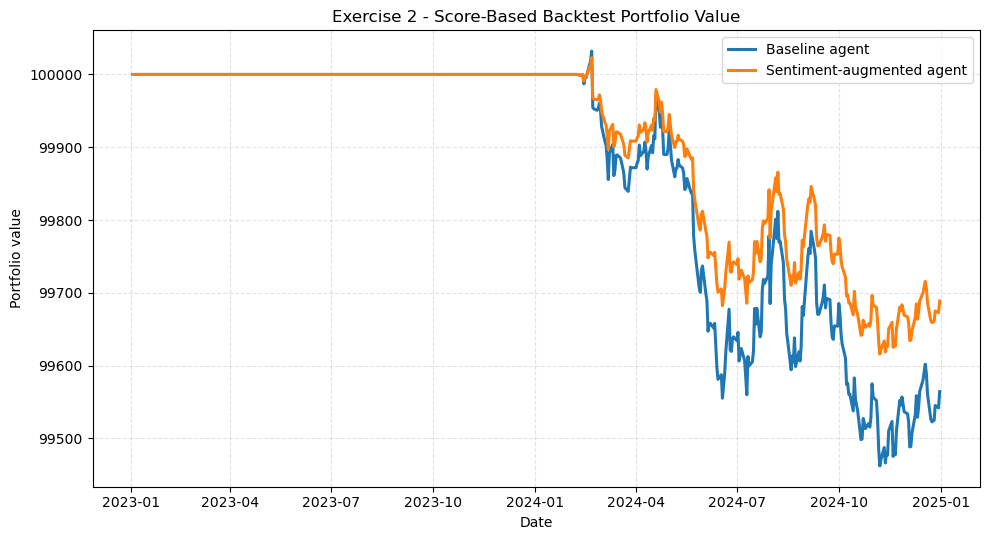

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5.5))

plt.plot(
    baseline_score_bt.index,
    baseline_score_bt["portfolio_value"],
    linewidth=2.2,
    label="Baseline agent",
)

plt.plot(
    sentiment_score_bt.index,
    sentiment_score_bt["portfolio_value"],
    linewidth=2.2,
    label="Sentiment-augmented agent",
)

plt.title("Exercise 2 - Score-Based Backtest Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio value")
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()